## *Import Necessary Libary*

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import random
from IPython import display

## *Import Dataset from google drive*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## *Data path set*

In [3]:
# Set the data directory path
DATA_DIR = '/content/drive/MyDrive/Data_set/archive/animals/animals'

## *Categories Loaded*

In [4]:
# Load image categories
def load_image(DATA_DIR):
    categories = os.listdir(DATA_DIR)
    return categories

print(load_image(DATA_DIR))
print(len(load_image(DATA_DIR)))

['cats', 'panda', 'dogs']
3


## *Train Data Function*

In [5]:
# Get trained data with images resized to (32x32)
def get_trained_data(categories):
    trained_data = []
    for c in categories:
        new_path = os.path.join(DATA_DIR, c)
        for img in tqdm(os.listdir(new_path)):
            label = categories.index(c)
            img_path = os.path.join(new_path, img)
            try:
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img_arr = cv2.resize(img_arr, (32, 32))  # Resize to 32x32
            except:
                pass
            trained_data.append([img_arr, label])

    random.shuffle(trained_data)
    return trained_data

# Load categories and get trained data
categories = load_image(DATA_DIR)
trained_data = get_trained_data(categories)


100%|██████████| 1000/1000 [00:52<00:00, 19.04it/s]


## *Showing images randomly*

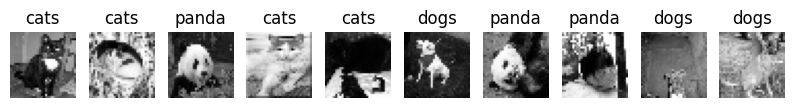

In [6]:
# Display 10 random images with their labels
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(trained_data[i][0], cmap='gray')
    plt.axis("off")
    plt.title(categories[trained_data[i][1]])  # Display the category name
plt.show()

In [7]:
len(trained_data)

3000

## *Model Building and Evaluation*

## *Distance function to calculate both L1 (Manhattan) and L2 (Euclidean) distances:*

In [8]:
def distance(train, valid, metric='L1'):
    if metric == 'L1':
        return np.sum(abs(train-valid))
    elif metric == 'L2':
        return np.sqrt(np.sum((train-valid)**2))

## *KNN function to calculate k nearest neighbors*

In [9]:
def KNN(validation_set, trained_set, k=5, metric='L1'):
    dist = []
    for v in tqdm(validation_set):
        for t in trained_set:
            d = distance(t[0], v[0], metric)
            labell = t[1]
            dist.append([d, labell, v[1]])
    dist.sort(key=lambda x: x[0])
    return dist[:k]

## *K-Fold cross-validation function*

In [10]:
# K-Fold cross-validation function
def KFOLD(trained_set, kf=5, k_nei=3, metric='L1'):
    point_dict = {k_nei: []}
    for i in range(kf):
        accuracy = 0
        test = trained_set[i*(int(len(trained_set)/kf)):(i+1)*int(len(trained_set)/kf)]
        first = trained_set[0:i*int(len(trained_set)/kf)]
        last = trained_set[(i+1)*int(len(trained_set)/kf):]
        trained = first + last
        pred = KNN(test, trained, k_nei, metric)
        print("-" * 20)
        print(f"FOLD-{i+1}")
        print(pred)
        for p in pred:
            if p[2] == p[1]:
                accuracy += 1
        final_acc = accuracy / k_nei
        point_dict[k_nei].append(final_acc)
        print(f"Accuracy: {final_acc*100:.2f}%")
        print("-" * 20)
    return point_dict

## *Function to display images array*

In [12]:
def show_image(img_matrix):
    plt.figure()
    plt.imshow(img_matrix, cmap='gray')
    plt.show()
print(trained_data[0][0])

[[118 118 118 ... 110 106 107]
 [121 120 120 ... 137 115 110]
 [123 124 123 ... 130 122 119]
 ...
 [ 83  85  85 ... 189 181 194]
 [ 87  90  97 ... 113 108 178]
 [102 107 101 ... 108 111 108]]


## *Load categories and get trained data*

In [13]:
catego = load_image(DATA_DIR)
trained_data = get_trained_data(catego)

100%|██████████| 1000/1000 [00:16<00:00, 60.64it/s]


## *Cross-validation with different values of K and both distance metrics*

In [14]:
K_nei = [2, 4, 6, 8, 10, 12]
points_L1 = []
points_L2 = []

for i in K_nei:
    print(f"K={i}, Metric=L1")
    point_L1 = KFOLD(trained_data, kf=5, k_nei=i, metric='L1')
    points_L1.append(point_L1)

    print(f"K={i}, Metric=L2")
    point_L2 = KFOLD(trained_data, kf=5, k_nei=i, metric='L2')
    points_L2.append(point_L2)


K=2, Metric=L1


100%|██████████| 600/600 [00:15<00:00, 38.89it/s]


--------------------
FOLD-1
[[55405, 0, 0], [55762, 0, 0]]
Accuracy: 100.00%
--------------------


100%|██████████| 600/600 [00:15<00:00, 37.79it/s]


--------------------
FOLD-2
[[48476, 2, 0], [58706, 2, 0]]
Accuracy: 0.00%
--------------------


...

--------------------
FOLD-3
[[199.1682705653689, 2, 2], [214.85576557309324, 0, 2], [228.55633878761708, 0, 2], [230.9502110845539, 0, 2], [237.70359694375682, 2, 2], [245.34873140083687, 2, 2], [247.71152577141015, 0, 2], [249.75588081164375, 2, 1], [251.51739502467817, 2, 2], [252.84580281270243, 2, 0], [253.17780313447702, 0, 1], [255.5327767625907, 2, 2]]
Accuracy: 41.67%
--------------------


100%|██████████| 600/600 [00:29<00:00, 20.33it/s]


--------------------
FOLD-4
[[199.1682705653689, 2, 2], [204.34774283069535, 0, 2], [232.0021551624036, 0, 2], [237.70359694375682, 2, 2], [246.70427641206385, 0, 0], [249.59166652755056, 2, 2], [249.75588081164375, 1, 2], [252.84580281270243, 0, 2], [255.96288793495046, 2, 2], [256.1581542719263, 2, 2], [257.2586247339436, 2, 0], [257.9399154842073, 2, 0]]
Accuracy: 50.00%
--------------------


100%|██████████| 600/600 [00:20<00:00, 28.70it/s]


--------------------
FOLD-5
[[145.11719401917887, 2, 2], [214.85576557309324, 2, 0], [230.9502110845539, 2, 0], [232.0021551624036, 2, 0], [245.34873140083687, 2, 2], [246.70427641206385, 0, 0], [248.9919677419334, 0, 0], [249.59166652755056, 2, 2], [251.51739502467817, 2, 2], [253.17780313447702, 1, 0], [254.8116951790086, 1, 0], [255.5327767625907, 2, 2]]
Accuracy: 58.33%
--------------------


## *Plotting the results*

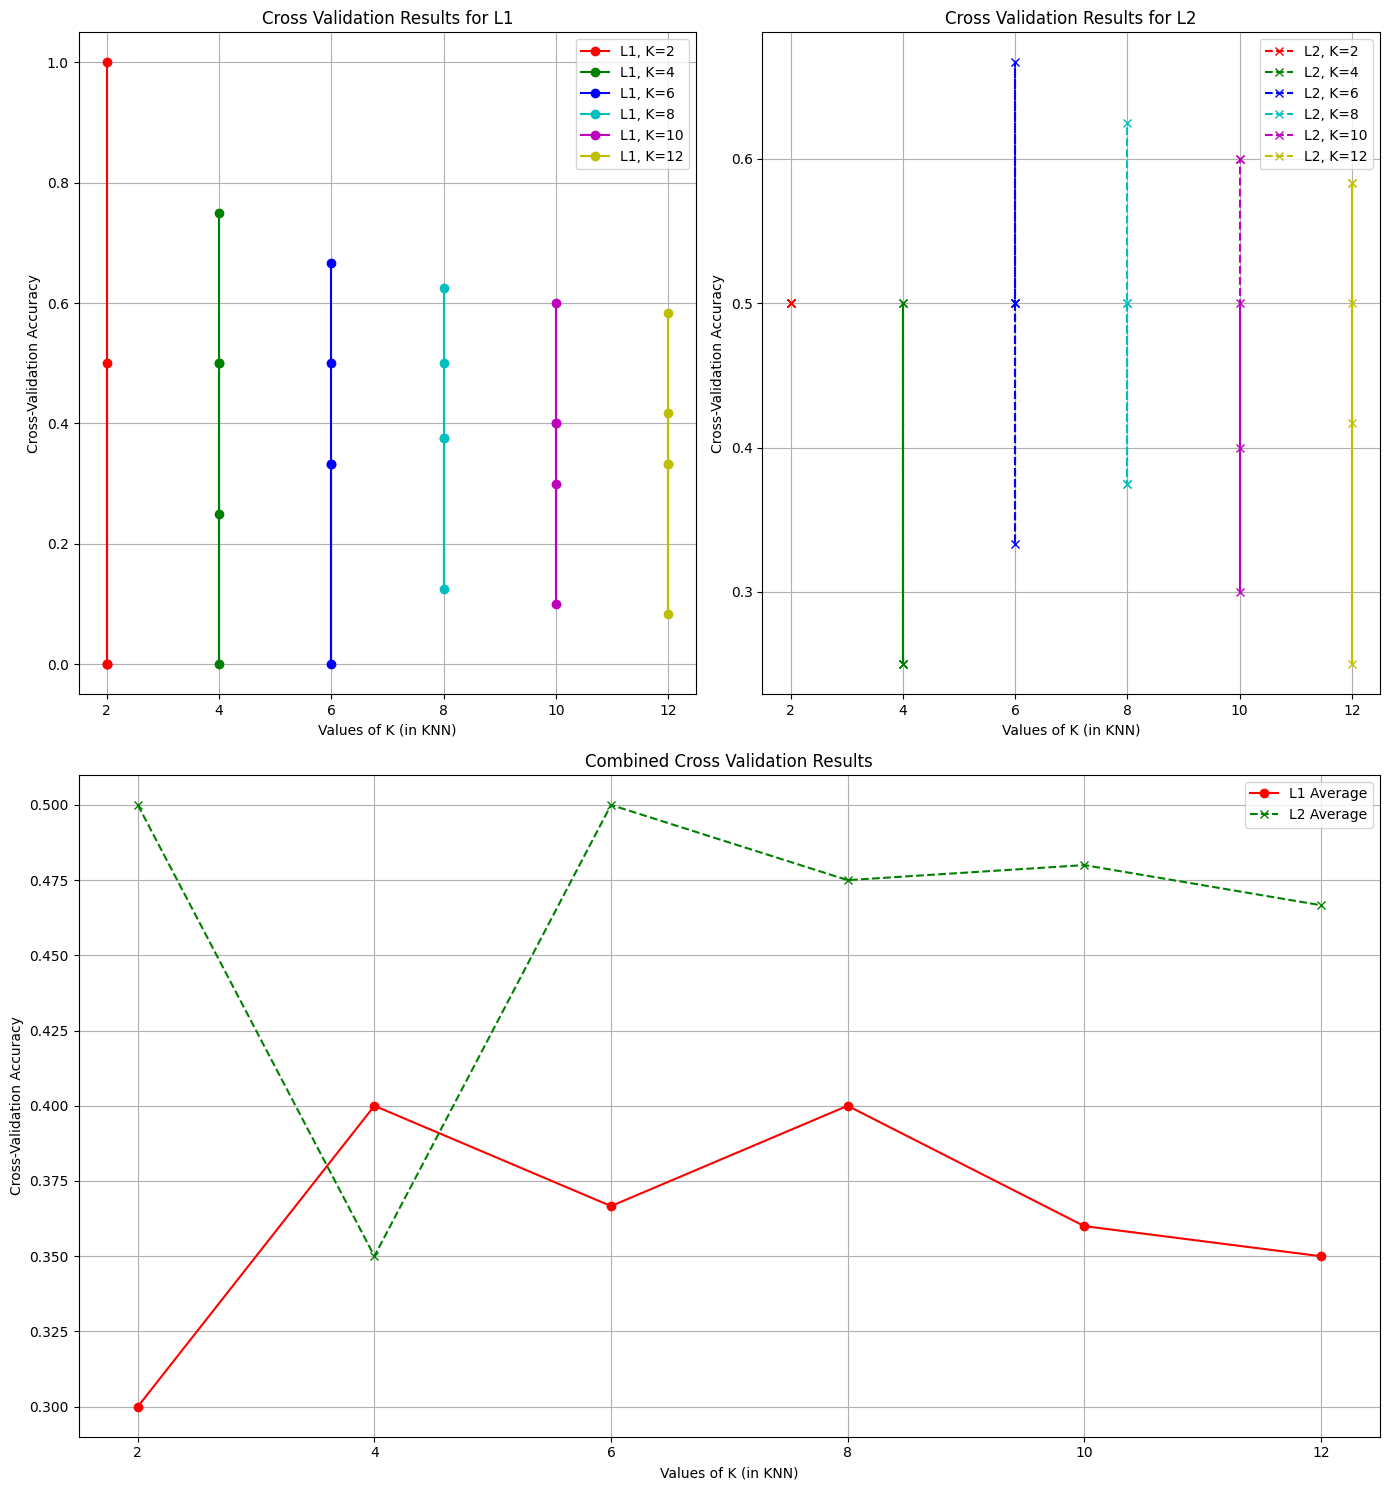

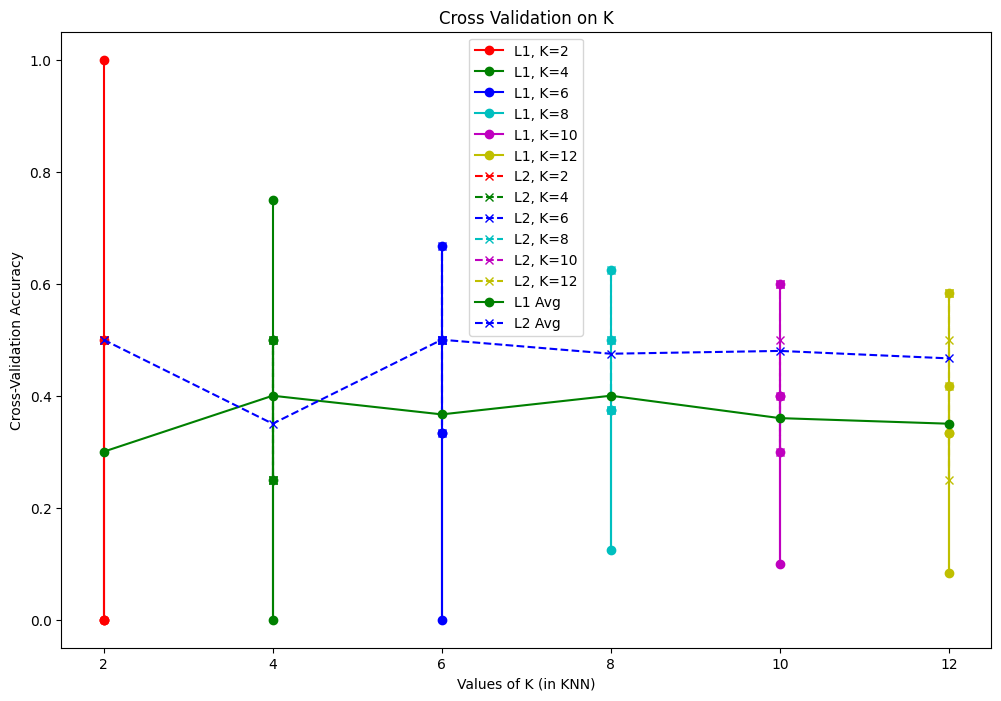

In [15]:
result_dict_L1 = {}
result_dict_L2 = {}

for item in points_L1:
    result_dict_L1.update(item)

for item in points_L2:
    result_dict_L2.update(item)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(14, 15))

# Individual Results for L1
plt.subplot(2, 2, 1)
plt.title("Cross Validation Results for L1")
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("Values of K (in KNN)")

# L1 Results
for idx2, (key, values) in enumerate(result_dict_L1.items()):
    x_values = [key] * len(values)
    plt.plot(x_values, values, marker='o', color=colors[idx2 % len(colors)], linestyle='-', label=f'L1, K={key}')

plt.legend()
plt.grid(True)

# Individual Results for L2
plt.subplot(2, 2, 2)
plt.title("Cross Validation Results for L2")
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("Values of K (in KNN)")

# L2 Results
for idx2, (key, values) in enumerate(result_dict_L2.items()):
    x_values = [key] * len(values)
    plt.plot(x_values, values, marker='x', color=colors[idx2 % len(colors)], linestyle='--', label=f'L2, K={key}')

plt.legend()
plt.grid(True)

# Combined Results
plt.subplot(2, 1, 2)
plt.title("Combined Cross Validation Results")
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("Values of K (in KNN)")

# Plot average accuracy for L1 and L2
K_values = sorted(set(result_dict_L1.keys()).union(result_dict_L2.keys()))
avg_L1_values = [np.mean(result_dict_L1.get(k, [])) for k in K_values]
avg_L2_values = [np.mean(result_dict_L2.get(k, [])) for k in K_values]

plt.plot(K_values, avg_L1_values, color='r', linestyle='-', marker='o', label='L1 Average')
plt.plot(K_values, avg_L2_values, color='g', linestyle='--', marker='x', label='L2 Average')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting the results for both L1 and L2
result_dict_L1 = {}
result_dict_L2 = {}
middle_point_L1 = []
middle_point_L2 = []

for item in points_L1:
    result_dict_L1.update(item)

for item in points_L2:
    result_dict_L2.update(item)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(12, 8))
plt.title("Cross Validation on K")
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("Values of K (in KNN)")

for idx2, (key, values) in enumerate(result_dict_L1.items()):
    avg_L1 = np.sum(values) / len(values)
    middle_point_L1.append(avg_L1)
    x_values = [key] * len(values)
    plt.plot(x_values, values, marker='o', color=colors[idx2 % len(colors)], linestyle='-', label=f'L1, K={key}')

for idx2, (key, values) in enumerate(result_dict_L2.items()):
    avg_L2 = np.sum(values) / len(values)
    middle_point_L2.append(avg_L2)
    x_values = [key] * len(values)
    plt.plot(x_values, values, marker='x', color=colors[idx2 % len(colors)], linestyle='--', label=f'L2, K={key}')

plt.plot(K_nei, middle_point_L1, marker='o', color='g', linestyle='-', label='L1 Avg')
plt.plot(K_nei, middle_point_L2, marker='x', color='b', linestyle='--', label='L2 Avg')

plt.legend()
plt.show()


## *Display the predictions value*

In [17]:
# Function to calculate distances for the validation set
def calculate_distances_for_validation_set(validation_set, trained_set, k_neighbours):
    distances_l1 = []
    distances_l2 = []

    for test_img in validation_set:
        l1_distances = []
        l2_distances = []

        for train_img in trained_set:
            distance_l1 = distance(train_img[0], test_img[0], metric='L1')
            distance_l2 = distance(train_img[0], test_img[0], metric='L2')

            l1_distances.append((distance_l1, train_img[1]))
            l2_distances.append((distance_l2, train_img[1]))

        l1_distances.sort(key=lambda x: x[0])
        l2_distances.sort(key=lambda x: x[0])

        distances_l1.append(l1_distances[:k_neighbours])
        distances_l2.append(l2_distances[:k_neighbours])

    return distances_l1, distances_l2

# Initialize lists to store predictions and corresponding distances
predictions_l1 = []
predictions_l2 = []

# Calculate distances for predictions
distances_l1, distances_l2 = calculate_distances_for_validation_set(trained_data, trained_data, k_neighbours=5)

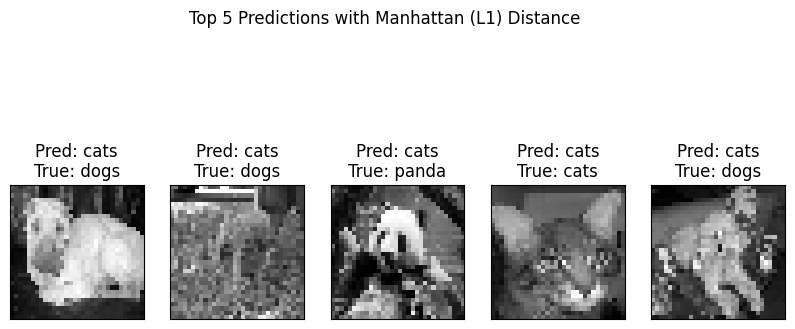

--------------------


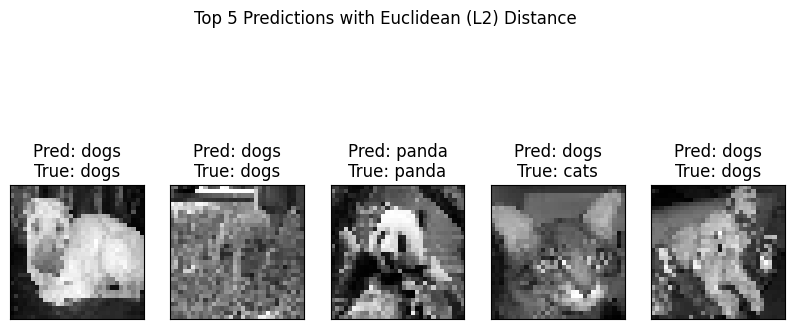

Accuracy percentage for top 5 predictions with Manhattan (L1) distance: 55.33%
Accuracy percentage for top 5 predictions with Euclidean (L2) distance: 72.33%


In [19]:
for test_img, l1, l2 in zip(trained_data, distances_l1, distances_l2):
    # For Manhattan (L1) distances
    n_neighbours_l1 = l1
    label_counts_l1 = {}
    label_min_distances_l1 = {}

    for i in range(5):
        label = n_neighbours_l1[i][1]
        distance = n_neighbours_l1[i][0]
        if label not in label_counts_l1:
            label_counts_l1[label] = 0
            label_min_distances_l1[label] = float('Inf')
        label_counts_l1[label] += 1
        label_min_distances_l1[label] = min(label_min_distances_l1[label], distance)

    max_count_l1 = max(label_counts_l1.values())
    candidates_l1 = [label for label, count in label_counts_l1.items() if count == max_count_l1]
    pred_label_l1 = min(candidates_l1, key=lambda label: label_min_distances_l1[label])

    # Store the prediction with its distances
    predictions_l1.append((test_img, pred_label_l1, l1))

    # For Euclidean (L2) distances
    n_neighbours_l2 = l2
    label_counts_l2 = {}
    label_min_distances_l2 = {}

    for i in range(5):
        label = n_neighbours_l2[i][1]
        distance = n_neighbours_l2[i][0]
        if label not in label_counts_l2:
            label_counts_l2[label] = 0
            label_min_distances_l2[label] = float('Inf')
        label_counts_l2[label] += 1
        label_min_distances_l2[label] = min(label_min_distances_l2[label], distance)

    max_count_l2 = max(label_counts_l2.values())
    candidates_l2 = [label for label, count in label_counts_l2.items() if count == max_count_l2]
    pred_label_l2 = min(candidates_l2, key=lambda label: label_min_distances_l2[label])

    # Store the prediction with its distances
    predictions_l2.append((test_img, pred_label_l2, l2))

# Function to display top 5 predictions
def display_top_predictions(predictions, title):
    plt.figure(figsize=(10, 5))

    for i in range(min(5, len(predictions))):
        test_img, pred_label, distances = predictions[i]
        true_label = test_img[1]

        plt.subplot(1, 5, i + 1)
        plt.imshow(test_img[0], cmap='gray')
        plt.title(f'Pred: {catego[pred_label]}\nTrue: {catego[true_label]}')
        plt.xticks([])
        plt.yticks([])

    plt.suptitle(title)
    plt.show()

# Display predictions for L1 and L2 distances
display_top_predictions(predictions_l1, "Top 5 Predictions with Manhattan (L1) Distance")
print("-" * 20)
display_top_predictions(predictions_l2, "Top 5 Predictions with Euclidean (L2) Distance")

# Function to calculate accuracy percentage
def calculate_accuracy_percentage(predictions):
    correct_predictions = 0
    total_predictions = len(predictions)

    for test_img, pred_label, _ in predictions:
        true_label = test_img[1]
        if pred_label == true_label:
            correct_predictions += 1

    accuracy_percentage = (correct_predictions / total_predictions) * 100
    return accuracy_percentage

# Calculate accuracy for top 5 predictions with L1 and L2 distances
accuracy_percentage_l1 = calculate_accuracy_percentage(predictions_l1)
accuracy_percentage_l2 = calculate_accuracy_percentage(predictions_l2)

print(f"Accuracy percentage for top 5 predictions with Manhattan (L1) distance: {accuracy_percentage_l1:.2f}%")
print(f"Accuracy percentage for top 5 predictions with Euclidean (L2) distance: {accuracy_percentage_l2:.2f}%")